# Comparing Marani-Inspired and Bernstein: Sensitivity to 1600-Present

- **Summary**: This document compares the our modified method from [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) and the method from [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183) using Marani's data. We test the effect of using data from 1600-present (instead of 1900-present) on Bernstein's hyperbolic parametrization.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral epidemic data

In [18]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [19]:
## Display all respiratory viral epidemics between 1500-present
# df_resp_viral

## 1. Set up exceedance probabilities from Madhav

In [20]:
## Read Madhav exceedance results from '03_resp_viral_comp'
df_madhav = pd.read_excel(cleandata_dir "exceedance_results" / "madhav_original.xlsx")


In [21]:
## Set severeity points automatically 
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
                15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
                200, 220, 230, 240, 250, 260, 270, 280]

## Set up severity points manually
# severity = df_madhav['severity']
# severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]

## 2. Calibrate Bernstein method with 1600-present data

In [22]:
## Subset epidemics to those with observable severities
df_resp_viral_known = df_resp_viral[df_resp_viral['death_thousand'] > 0
                                   ].reset_index(drop=True)

## Subset epidemics to those in the last century
df_resp_viral_known = df_resp_viral_known[
                        df_resp_viral_known['year_start'] >= 1600
                                        ].reset_index(drop=True)

## Display subsetted data
df_resp_viral_known


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.000,8.698400e+05,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,west washington influenza,1836,1837,2,8.000,1.147067e+06,0.006974,0.069743,influenza,viral,droplet,1,0,1,0
2,russian flu,1889,1890,2,1310.000,1.497480e+06,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
3,"usa, yukon",1900,1900,1,0.100,1.633000e+06,0.000061,0.000612,influenza,viral,droplet,1,0,1,0
4,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
5,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0
6,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
7,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
8,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0
9,global sars,2003,2003,1,0.744,6.381185e+06,0.000117,0.001166,sars,viral,droplet,1,0,1,1


In [23]:
## Define extreme severity threshold 
thresh = 10  ## Set to 10 SMU in accordance with Bernstein and Fan

## Define arrival and mean severity of all epidemics
p_a = 8 / 70  ## 8 epidemics in the past 70 years
mu_a = np.mean(df_resp_viral_known['severity_smu']) ## mean severity of all epidemics

## Define arrival and mean severity of extreme epidemics
p_x = 1 / 100  ## 1 extreme epidemic (1918 flu) in 100 years
mu_x = np.mean(df_resp_viral_known['severity_smu'][
    df_resp_viral_known['severity_smu'] >= thresh])  ## mean severity of extreme epidemics


In [24]:
## Find expected annual SMUs of all and extreme outbreaks
s_a = round(p_a * mu_a, 2)  ## expected annual severity of all outbreaks
s_x = round(p_x * mu_x, 2)  ## expected annual severity of extreme outbreaks

## Calibrate 'm'
m = round(1/(s_a), 2)  ## round 'm' to 2 decimals

## Display expected severities
print(f'Expected annual severity of all epidemics: {s_a} SMU')
print(f'Expected annual severity of extreme epidemics: {s_x} SMU')


Expected annual severity of all epidemics: 1.63 SMU
Expected annual severity of extreme epidemics: 1.71 SMU


In [25]:
## Define function to calibrate 'f' with conditional first moment
def calibrate_hyperbolic_f(m, thresh, s_x):
    """
    Calibrate the parameter 'f' for a hyperbolic function from Fan et al. 
    (2018) based on the first moment conditional on exceedance.

    Parameters:
    - m: float, parameter of the hyperbolic model.
    - thresh: float, threshold value for extreme severities.
    - s_x: float, annual expected extreme severity.

    Returns:
    - f_opt: float, the optimal value of 'f' that minimizes the difference 
      between the integral and the conditional first moment.
    """
    
    ## Define integrand for hyperbolic exceedance
    def integrand(s, m, f):
        return (1 + m * (1 - f) * s) ** (-1 - 1 / (1 - f))
    
    ## Define the objective function to minimize
    def objective(f, m, s_x):
        integral, _ = quad(integrand, thresh, np.inf, args=(m, f))
        return (s_x - integral) ** 2
    
    ## Set bounds for 'f'
    bounds = [(-200, -1)]
    
    ## Minimize difference between integral and conditional moment
    ## x0 is the initial guess for 'f'
    result = minimize(objective, x0=-2, args=(m, s_x), bounds=bounds)
    
    ## Print result
    if result.success:
        if result.fun < 1e-08:
            print("Convergence succeeded! :)")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
        else:
            print("Convergence failed. :(")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
    else:
        print("Optimization failed. :(")
        print("Objective function value: NA")
    
    ## Return optimal value of 'f'
    f_opt = result.x[0] if result.success else None
    return f_opt

## Example usage:
## m = 0.23
## thresh = 10
## s_x = 2.97
## f = calibrate_hyperbolic_f(m, thresh, s_x)    


In [26]:
## Calibrate 'f'
f = calibrate_hyperbolic_f(m, thresh, s_x) 
f = round(f, 2)  ## round 'f' to 2 decimals


Convergence failed. :(
Minimized cost value: 0.016294474472149302
Optimal value of f: -200.0


In [27]:
print(f'Result: m = {m}, f = {f}')

Result: m = 0.61, f = -200.0


In [28]:
## Calculate Bernstein exceedance probabilities
exceedance = [(1 + m * (1 - f) * s)**(-1 - 1/(1 - f)) for s in severity]

## Create dataframe on exceedance probabilities
df_bernstein_1600 = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index
df_bernstein_1600 = df_bernstein_1600.sort_values(by='severity', ascending=True)
df_bernstein_1600 = df_bernstein_1600.reset_index(drop=True)

## Display severities and exceedance probabilities
df_bernstein_1600

## Save to exceedance results folder
df_bernstein_1600.to_excel(cleandata_dir / "exceedance_results" / "bernstein_1600.xlsx", index=False)


,severity,exceedance
0,0.01,0.447431
1,0.04,0.167876
2,0.07,0.103188
3,0.08,0.091428
4,0.10,0.074446
5,0.40,0.019597
6,0.70,0.011264
7,1.00,0.007898
8,4.00,0.001973
9,7.00,0.001125


## 3. Calculate empirical exceedance probabilities

In [29]:
## Set arrival rate epidemics with known severities conditional upon first arrival
arrival_known = (df_resp_viral_known.shape[0] - 1) / (2019 - 1781)

## Create a ranked df by historical severities 
df_resp_viral_ranked = df_resp_viral_known.sort_values(by='severity_smu', 
                                                       ascending=False).reset_index(drop=True)

## Calculate exceedance conditional on known-severity arrival
df_resp_viral_ranked['exceed_upon_arrival'] = (df_resp_viral_ranked.index + 1) / (df_resp_viral_ranked.shape[0] + 1)

## Create empirical exceedance probabilities
df_resp_viral_ranked['exceedance'] = arrival_known * df_resp_viral_ranked['exceed_upon_arrival']

In [30]:
## Create df for empirical exceedance
df_empirical_1600 = pd.DataFrame({
    'severity': df_resp_viral_ranked['severity_smu'],
    'exceedance': df_resp_viral_ranked['exceedance'],
    'year_start': df_resp_viral_ranked['year_start'],
    'disease': df_resp_viral_ranked['disease']
})

## Display
df_empirical_1600

## Save to exceedance results folder
df_empirical_1600.to_excel(cleandata_dir / "exceedance_results" / "empirical_1600.xlsx", index=False)


,severity,exceedance,year_start,disease
0,170.821545,0.003641,1918,influenza
1,9.173127,0.007283,2019,covid-19
2,8.748030,0.010924,1889,influenza
3,6.960623,0.014566,1957,influenza
4,2.815633,0.018207,1968,influenza
5,1.149637,0.021849,1781,influenza
6,0.413953,0.025490,2009,influenza
7,0.069743,0.029132,1836,influenza
8,0.008274,0.032773,1969,influenza
9,0.002710,0.036415,2015,influenza


## 4. Visualize models on 1600-present data and empirical exceedance

In [31]:
## Read exceedance results from benchmark models
df_marani_inspired = pd.read_excel(cleandata_dir / "exceedance_results" / "marani_inspired.xlsx")
df_bernstein = pd.read_excel(cleandata_dir / "exceedance_results" / "bernstein_original.xlsx")


In [32]:
df_marani_inspired

,severity,exceedance
0,0.01,0.100000
1,0.04,0.098763
2,0.07,0.097564
3,0.08,0.097173
4,0.10,0.096401
5,0.40,0.086406
6,0.70,0.078648
7,1.00,0.072422
8,4.00,0.043253
9,7.00,0.032434


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.01, 1000.0)

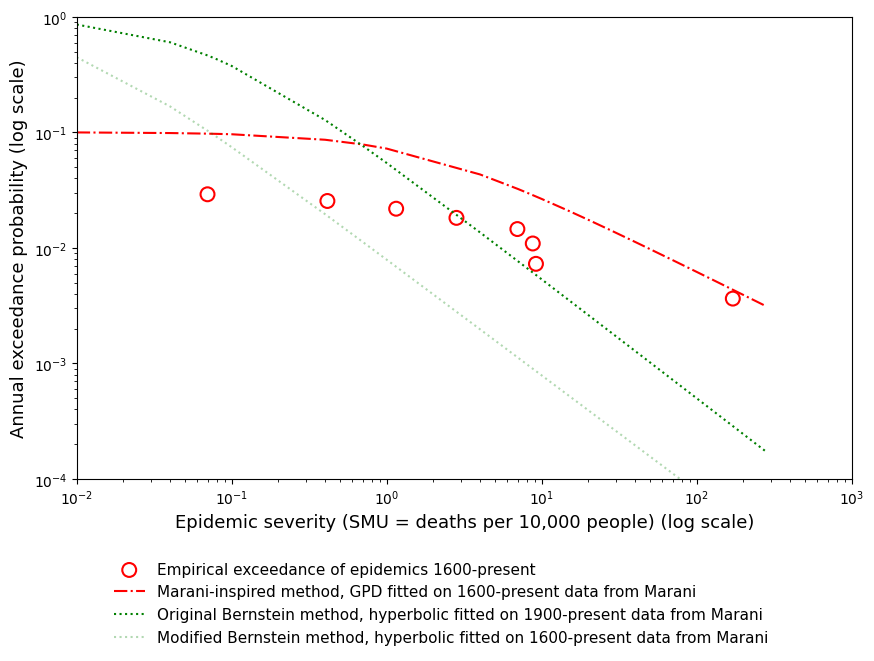

In [33]:
## Plot comparison across Marani and Bernstein
plt.figure(figsize=(10, 6))

## Plot empirical exceedances of epidemics from 1600-present
plt.scatter(df_empirical_1600['severity'], df_empirical_1600['exceedance'], 
            edgecolor='red', facecolor='none', s=100, linewidth=1.5,
            label='Empirical exceedance of epidemics 1600-present')


## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present data from Marani')


## Plot for Bernstein original
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
         color='green', linestyle=':', alpha=1,
         label='Original Bernstein method, hyperbolic fitted on 1900-present data from Marani')

## Plot for Bernstein fitted on 1600-present
plt.plot(df_bernstein_1600['severity'], df_bernstein_1600['exceedance'], 
         color='green', linestyle=':', alpha=0.3,
         label='Modified Bernstein method, hyperbolic fitted on 1600-present data from Marani')


# ## Plot for Madhav
# plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
#          color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Bernstein Method: Sensitivity to 1600-Present Data', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '06a_sensitivity_data_1600.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()
